## Dataset helpers testing script

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

from model.data_utils import (
    ZINBDataset,
    get_X_features,
    get_reference_features,
    load_expression_dataset,
)
from model.model_utils import (
    OrionLoss,
    OrionVAE,
    evaluate_test_set,
    plot_training_results,
    run_dataset_inference,
    train_orion,
)

TRAIN_DATASET = "tissue"  # "tissue" or "circulating"
N_SIGNAL_FEATURES = 20
N_REFERENCE_FEATURES = 50
FEATURE_METHOD = "mannwhitneyu"
BATCH_SIZE = 8
RANDOM_STATE = 42
SEEDS = [7, 11, 19, 29, 42]
EPOCHS = 80
LEARNING_RATE = 1e-3
USE_FEATURE_LEAKAGE = False  # Requested: feature selection on full dataset (leaky)
MODEL_PATH = Path("model/orion_breast_cancer_model.pth")

counts_matrix, labels = load_expression_dataset(TRAIN_DATASET)
print(f"Loaded {TRAIN_DATASET} dataset with shape {counts_matrix.shape}")
print(f"Class counts: cancer={int(labels.sum())}, healthy={int((labels == 0).sum())}")


def run_multisplit_experiment(
    counts_df,
    labels_array,
    dataset_tag,
    seeds,
    epochs,
    lr,
    device,
    n_signal_features,
    n_reference_features,
    feature_method,
    batch_size,
    use_feature_leakage=True,
):
    split_rows = []
    best_artifact = None
    best_auc = -1.0

    for split_seed in seeds:
        print("\n" + "=" * 60)
        print(f"{dataset_tag.upper()} | split seed={split_seed}")
        print("=" * 60)

        indices = np.arange(len(labels_array))
        train_val_idx, test_idx = train_test_split(
            indices,
            test_size=0.15,
            stratify=labels_array,
            random_state=split_seed,
        )
        train_idx, val_idx = train_test_split(
            train_val_idx,
            test_size=0.176,
            stratify=labels_array[train_val_idx],
            random_state=split_seed,
        )

        if use_feature_leakage:
            select_counts = counts_df
            select_labels = labels_array
        else:
            select_counts = counts_df.iloc[train_idx]
            select_labels = labels_array[train_idx]

        signal_cols_local = get_X_features(
            select_counts,
            select_labels,
            method=feature_method,
            n_features=n_signal_features,
        )
        ref_cols_local = get_reference_features(
            select_counts,
            n_features=n_reference_features,
        )

        full_dataset_local = ZINBDataset(counts_df, labels_array, signal_cols_local, ref_cols_local)
        train_loader_local = DataLoader(Subset(full_dataset_local, train_idx), batch_size=batch_size, shuffle=True)
        val_loader_local = DataLoader(Subset(full_dataset_local, val_idx), batch_size=batch_size, shuffle=False)
        test_loader_local = DataLoader(Subset(full_dataset_local, test_idx), batch_size=batch_size, shuffle=False)

        model_local = OrionVAE(
            x_dim=len(signal_cols_local),
            r_dim=len(ref_cols_local),
            z_dim=32,
        )

        history_local = train_orion(
            model=model_local,
            train_loader=train_loader_local,
            val_loader=val_loader_local,
            epochs=epochs,
            lr=lr,
            device=device,
        )

        loss_fn_local = OrionLoss(beta=0.01, gamma=10.0).to(device)
        test_probs_local, test_targets_local = evaluate_test_set(
            model_local,
            test_loader_local,
            loss_fn_local,
            device,
        )

        split_auc = roc_auc_score(test_targets_local, test_probs_local)
        split_acc = accuracy_score(test_targets_local, (test_probs_local > 0.5).astype(int))

        split_rows.append(
            {
                "seed": split_seed,
                "test_auc": split_auc,
                "test_acc": split_acc,
                "n_train": len(train_idx),
                "n_val": len(val_idx),
                "n_test": len(test_idx),
            }
        )

        if split_auc > best_auc:
            best_auc = split_auc
            best_artifact = {
                "seed": split_seed,
                "model": model_local,
                "history": history_local,
                "signal_cols": signal_cols_local,
                "ref_cols": ref_cols_local,
                "test_loader": test_loader_local,
                "test_probs": test_probs_local,
                "test_targets": test_targets_local,
            }

    summary_df = pd.DataFrame(split_rows)
    print("\n--- Multi-split Summary ---")
    print(summary_df)
    print(
        f"AUC mean={summary_df['test_auc'].mean():.4f} std={summary_df['test_auc'].std(ddof=0):.4f} | "
        f"ACC mean={summary_df['test_acc'].mean():.4f} std={summary_df['test_acc'].std(ddof=0):.4f}"
    )
    print(f"Best split seed={best_artifact['seed']} AUC={best_auc:.4f}")

    return summary_df, best_artifact



Loaded tissue dataset with shape (180, 3538)
Class counts: cancer=120, healthy=60


## Running the model
1. Split data into training and validation sets.
2. Initialize the model with the correct dimensions.
3. Execute the training loop using the train_orion function.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [3]:
if "signal_cols" not in globals() or "ref_cols" not in globals():
    print("Run the split/feature-selection cell first to initialize signal_cols/ref_cols.")
else:
    dataset_preview = ZINBDataset(counts_matrix, labels, signal_cols, ref_cols)
    preview_loader = DataLoader(dataset_preview, batch_size=BATCH_SIZE, shuffle=True)

    x_batch, r_batch, l_batch, y_batch = next(iter(preview_loader))
    print(f"Batch X Shape: {x_batch.shape}")
    print(f"Batch R Shape: {r_batch.shape}")
    print("Data pipeline ready!")


Run the split/feature-selection cell first to initialize signal_cols/ref_cols.


In [4]:
print(
    f"Preparing 5-split experiment for {TRAIN_DATASET} | "
    f"epochs={EPOCHS} | leakage={USE_FEATURE_LEAKAGE}"
)


Preparing 5-split experiment for tissue | epochs=80 | leakage=False


In [5]:
# Model is created inside each split in the multi-split runner.


In [6]:
print("\n--- Starting Multi-Split Training ---")
primary_summary_df, primary_best = run_multisplit_experiment(
    counts_df=counts_matrix,
    labels_array=labels,
    dataset_tag=TRAIN_DATASET,
    seeds=SEEDS,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    n_signal_features=N_SIGNAL_FEATURES,
    n_reference_features=N_REFERENCE_FEATURES,
    feature_method=FEATURE_METHOD,
    batch_size=BATCH_SIZE,
    use_feature_leakage=USE_FEATURE_LEAKAGE,
)

model = primary_best["model"]
history = primary_best["history"]
signal_cols = primary_best["signal_cols"]
ref_cols = primary_best["ref_cols"]
test_loader = primary_best["test_loader"]
test_probs = primary_best["test_probs"]
test_targets = primary_best["test_targets"]

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved best {TRAIN_DATASET} model to '{MODEL_PATH}'")



--- Starting Multi-Split Training ---

TISSUE | split seed=7
Selecting top 20 signal features...
Starting training on cpu for 80 epochs...
Epoch 005 | Loss: 1153.2962 | Val AUC: 1.0000 | Val Acc: 0.6667
Epoch 010 | Loss: 832.0734 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 015 | Loss: 662.4957 | Val AUC: 1.0000 | Val Acc: 0.9259
Epoch 020 | Loss: 635.9250 | Val AUC: 1.0000 | Val Acc: 0.9259
Epoch 025 | Loss: 620.1351 | Val AUC: 1.0000 | Val Acc: 0.9259
Epoch 030 | Loss: 610.0167 | Val AUC: 1.0000 | Val Acc: 0.9259
Epoch 035 | Loss: 602.0717 | Val AUC: 1.0000 | Val Acc: 0.9259
Epoch 040 | Loss: 597.2218 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 045 | Loss: 589.8280 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 050 | Loss: 586.8278 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 055 | Loss: 583.2485 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 060 | Loss: 575.5459 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 065 | Loss: 571.1025 | Val AUC: 1.0000 | Val Acc: 0.9630
Epoch 070 | Loss: 566.8019 | Val AUC: 1.

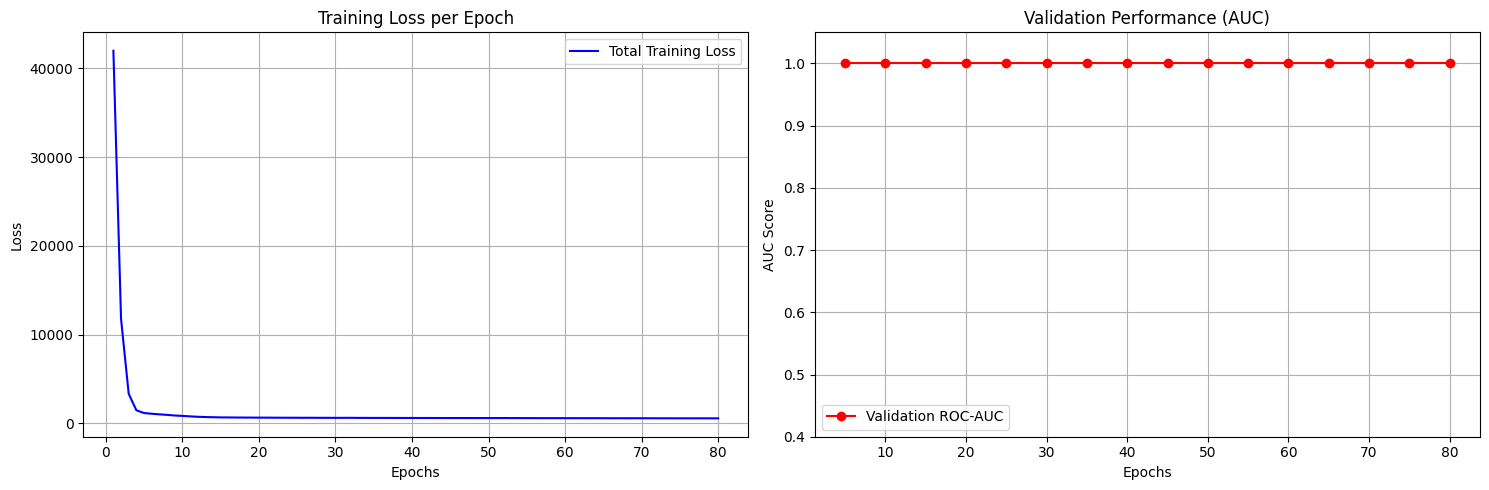

In [7]:
plot_training_results(history)


In [8]:
print("Primary dataset 5-split summary:")
print(primary_summary_df)
print(
    f"AUC mean={primary_summary_df['test_auc'].mean():.4f} | "
    f"ACC mean={primary_summary_df['test_acc'].mean():.4f}"
)
print(f"Downstream plots use best-seed model: {primary_best['seed']}")


Primary dataset 5-split summary:
   seed  test_auc  test_acc  n_train  n_val  n_test
0     7  1.000000  0.925926      126     27      27
1    11  0.993827  0.925926      126     27      27
2    19  0.950617  0.925926      126     27      27
3    29  0.981481  0.888889      126     27      27
4    42  1.000000  1.000000      126     27      27
AUC mean=0.9852 | ACC mean=0.9333
Downstream plots use best-seed model: 7



--- Starting Circulating Multi-Split Training ---

CIRCULATING | split seed=7
Selecting top 20 signal features...
Starting training on cpu for 80 epochs...
Epoch 005 | Loss: 598.1364 | Val AUC: 0.6296 | Val Acc: 0.6000
Epoch 010 | Loss: 399.1962 | Val AUC: 0.9630 | Val Acc: 0.9333
Epoch 015 | Loss: 330.7482 | Val AUC: 0.9630 | Val Acc: 0.9333
Epoch 020 | Loss: 311.8730 | Val AUC: 0.9630 | Val Acc: 0.9333
Epoch 025 | Loss: 296.3866 | Val AUC: 0.9815 | Val Acc: 0.9333
Epoch 030 | Loss: 282.8764 | Val AUC: 0.9815 | Val Acc: 0.8667
Epoch 035 | Loss: 275.2679 | Val AUC: 0.9815 | Val Acc: 0.9333
Epoch 040 | Loss: 262.6010 | Val AUC: 0.9815 | Val Acc: 0.9333
Epoch 045 | Loss: 256.2386 | Val AUC: 0.9815 | Val Acc: 0.9333
Epoch 050 | Loss: 256.5962 | Val AUC: 0.9815 | Val Acc: 0.8667
Epoch 055 | Loss: 246.0786 | Val AUC: 0.9815 | Val Acc: 0.9333
Epoch 060 | Loss: 247.1689 | Val AUC: 0.9815 | Val Acc: 0.9333
Epoch 065 | Loss: 231.9465 | Val AUC: 0.9815 | Val Acc: 0.9333
Epoch 070 | Loss: 231.41

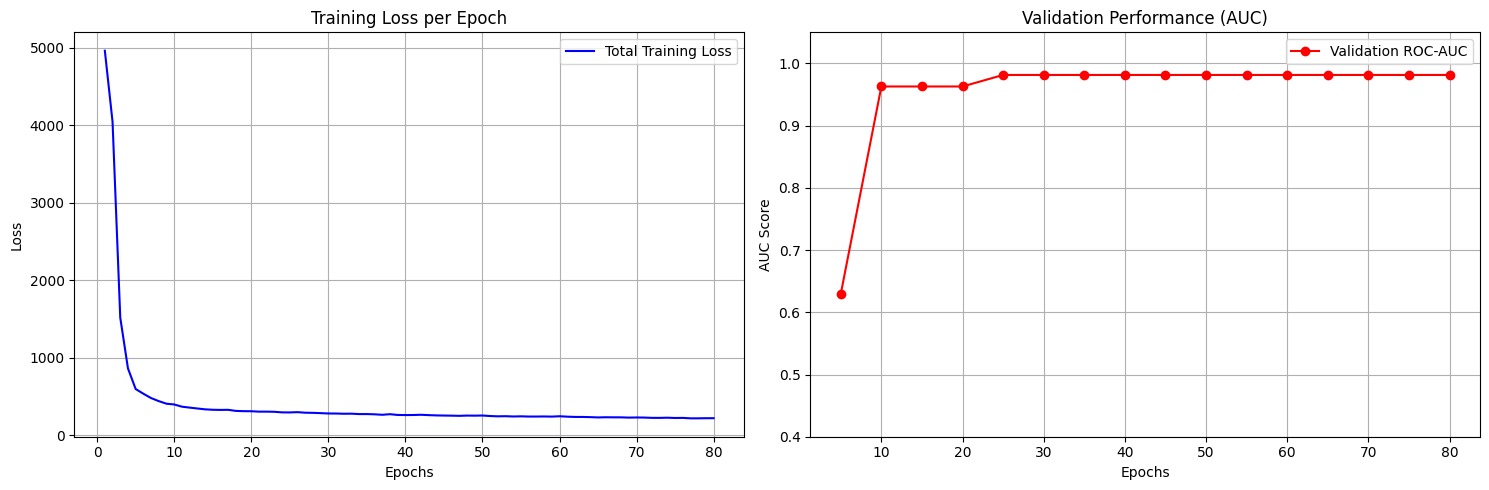

Saved best circulating model to 'model\orion_circulating_model.pth'


In [9]:
# Additional experiment: train and evaluate on circulating RNA (5-split average)
CIRCULATING_EPOCHS = EPOCHS

counts_circ, labels_circ = load_expression_dataset("circulating")

print("\n--- Starting Circulating Multi-Split Training ---")
circ_summary_df, circ_best = run_multisplit_experiment(
    counts_df=counts_circ,
    labels_array=labels_circ,
    dataset_tag="circulating",
    seeds=SEEDS,
    epochs=CIRCULATING_EPOCHS,
    lr=LEARNING_RATE,
    device=device,
    n_signal_features=N_SIGNAL_FEATURES,
    n_reference_features=N_REFERENCE_FEATURES,
    feature_method=FEATURE_METHOD,
    batch_size=BATCH_SIZE,
    use_feature_leakage=USE_FEATURE_LEAKAGE,
)

model_circ = circ_best["model"]
history_circ = circ_best["history"]
signal_cols_circ = circ_best["signal_cols"]
ref_cols_circ = circ_best["ref_cols"]
test_loader_circ = circ_best["test_loader"]
test_probs_circ = circ_best["test_probs"]
test_targets_circ = circ_best["test_targets"]

plot_training_results(history_circ)

model_circ_path = Path("model/orion_circulating_model.pth")
model_circ_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model_circ.state_dict(), model_circ_path)
print(f"Saved best circulating model to '{model_circ_path}'")


In [10]:
print("Primary dataset 5-split summary:")
print(circ_summary_df)
print(
    f"AUC mean={circ_summary_df['test_auc'].mean():.4f} | "
    f"ACC mean={circ_summary_df['test_acc'].mean():.4f}"
)
print(f"Downstream plots use best-seed model: {circ_best['seed']}")


Primary dataset 5-split summary:
   seed  test_auc  test_acc  n_train  n_val  n_test
0     7  1.000000  0.933333       66     15      15
1    11  0.740741  0.666667       66     15      15
2    19  0.666667  0.533333       66     15      15
3    29  0.944444  0.933333       66     15      15
4    42  0.851852  0.800000       66     15      15
AUC mean=0.8407 | ACC mean=0.7733
Downstream plots use best-seed model: 7


c:\Users\eliaa\miniconda3\envs\TorMPNN\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\eliaa\miniconda3\envs\TorMPNN\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


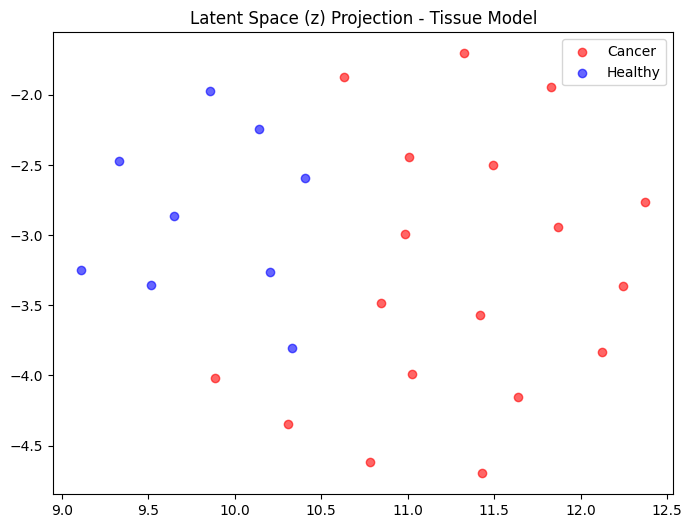

c:\Users\eliaa\miniconda3\envs\TorMPNN\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\eliaa\miniconda3\envs\TorMPNN\Lib\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


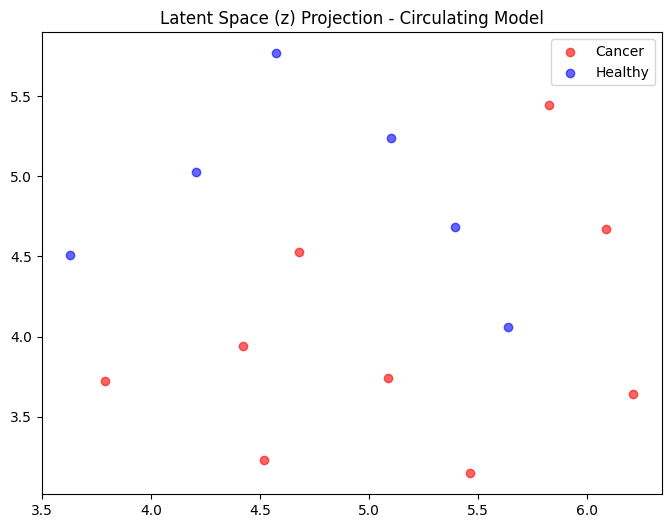

In [11]:
from umap import UMAP
import matplotlib.pyplot as plt

def plot_latent_space(model_obj, loader_obj, device, title):
    model_obj.eval()
    latents = []
    labels_local = []

    with torch.no_grad():
        for x, r, _, y in loader_obj:
            z, _, _, _, _, _ = model_obj.encoder(x.to(device), r.to(device))
            latents.append(z.cpu().numpy())
            labels_local.append(y.numpy())

    latents = np.concatenate(latents)
    labels_local = np.concatenate(labels_local).flatten()

    reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(latents)

    plt.figure(figsize=(8, 6))
    plt.scatter(
        embedding[labels_local == 1, 0],
        embedding[labels_local == 1, 1],
        c="red",
        label="Cancer",
        alpha=0.6,
    )
    plt.scatter(
        embedding[labels_local == 0, 0],
        embedding[labels_local == 0, 1],
        c="blue",
        label="Healthy",
        alpha=0.6,
    )
    plt.title(title)
    plt.legend()
    plt.show()

# 1) Tissue-only model latent projection (classic style)
plot_latent_space(model, test_loader, device, "Latent Space (z) Projection - Tissue Model")

# 2) Circulating-only model latent projection (classic style)
if "model_circ" in globals() and "test_loader_circ" in globals():
    plot_latent_space(
        model_circ,
        test_loader_circ,
        device,
        "Latent Space (z) Projection - Circulating Model",
    )
else:
    print("Run the circulating multi-split cell first to plot circulating latent space.")


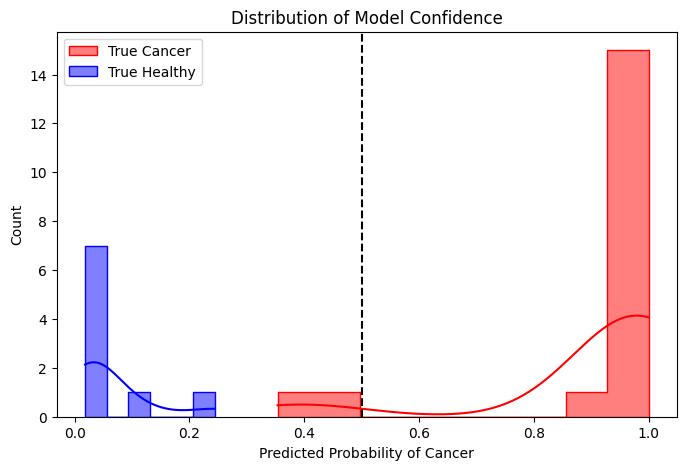

In [12]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(test_probs[test_targets == 1], color="red", label="True Cancer", kde=True, element="step")
sns.histplot(test_probs[test_targets == 0], color="blue", label="True Healthy", kde=True, element="step")
plt.axvline(0.5, color="black", linestyle="--")
plt.title("Distribution of Model Confidence")
plt.xlabel("Predicted Probability of Cancer")
plt.legend()
plt.show()


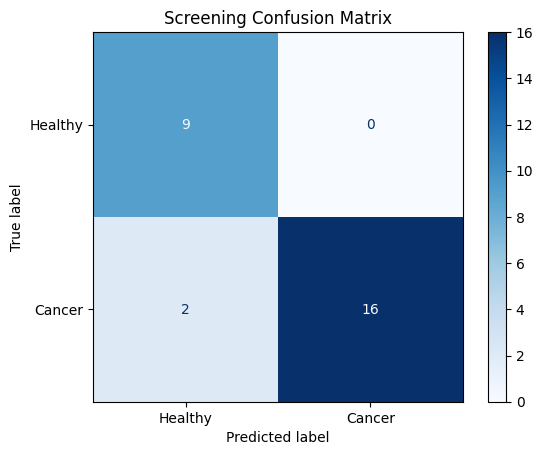

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

preds_binary = (test_probs > 0.5).astype(int)
cm = confusion_matrix(test_targets, preds_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Cancer"])
disp.plot(cmap="Blues")
plt.title("Screening Confusion Matrix")
plt.show()


In [14]:
from sklearn.metrics import accuracy_score, roc_auc_score

INFERENCE_DATASET = "circulating" if TRAIN_DATASET == "tissue" else "tissue"
inference_counts, inference_labels = load_expression_dataset(INFERENCE_DATASET)

signal_overlap = len(set(signal_cols).intersection(inference_counts.columns))
ref_overlap = len(set(ref_cols).intersection(inference_counts.columns))
print(
    f"Feature overlap with {INFERENCE_DATASET}: signal {signal_overlap}/{len(signal_cols)}, "
    f"reference {ref_overlap}/{len(ref_cols)}"
)

inference_probs, inference_targets = run_dataset_inference(
    model=model,
    counts_df=inference_counts,
    signal_features=signal_cols,
    ref_features=ref_cols,
    labels=inference_labels,
    batch_size=BATCH_SIZE,
    device=device,
)

inference_binary = (inference_probs > 0.5).astype(int)
inference_auc = roc_auc_score(inference_targets, inference_probs)
inference_acc = accuracy_score(inference_targets, inference_binary)

print(f"{TRAIN_DATASET} -> {INFERENCE_DATASET} inference AUC: {inference_auc:.4f}")
print(f"{TRAIN_DATASET} -> {INFERENCE_DATASET} inference ACC: {inference_acc:.4f}")


Feature overlap with circulating: signal 14/20, reference 25/50
tissue -> circulating inference AUC: 0.3513
tissue -> circulating inference ACC: 0.4062
